# Exercice 3 :

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

Minimum kLa required = 29.50 h^-1


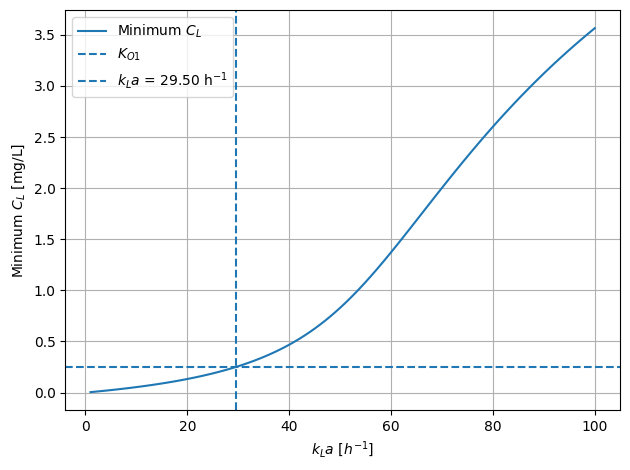

In [ ]:
# Exercice 3.b):

# Parameters
vm1 = 125      # mg/L.h
vm2 = 75       # mg/L.h
K1 = 5.0       # mg/L
K2 = 3.0       # mg/L
KO1 = 0.25     # mg/L
KO2 = 0.5      # mg/L

YO_S1 = 3.5    # mg O2 / mg S1
YO_S2 = 1.1    # mg O2 / mg S2

CL_star = 8.0  # mg/L

# Initial conditions
S1_0 = 100.0
S2_0 = 0.0
S3_0 = 0.0
CL_0 = 7.0

y0 = [S1_0, S2_0, S3_0, CL_0]


def system(t, y, kLa):
    S1, S2, S3, CL = y

    # Avoid negative numerical values
    S1 = max(S1, 0)
    S2 = max(S2, 0)
    CL = max(CL, 0)

    r1 = vm1 * S1 / (K1 + S1) * CL / (KO1 + CL)
    r2 = vm2 * S2 / (K2 + S2) * CL / (KO2 + CL)

    dS1dt = -r1
    dS2dt = r1 - r2
    dS3dt = r2
    dCLdt = kLa * (CL_star - CL) - YO_S1 * r1 - YO_S2 * r2

    return [dS1dt, dS2dt, dS3dt, dCLdt]


def minimum_CL(kLa):
    sol = solve_ivp(
        lambda t, y: system(t, y, kLa),
        t_span=(0, 20),
        y0=y0,
        method="BDF",
        rtol=1e-8,
        atol=1e-10,
        max_step=0.01
    )
    return np.min(sol.y[3])


# Scan kLa values
kLa_values = np.linspace(1, 100, 100)
CL_min_values = np.array([minimum_CL(kLa) for kLa in kLa_values])

# Find minimum kLa such that CL_min = KO1
kLa_min = brentq(lambda kLa: minimum_CL(kLa) - KO1, 1, 100)

print(f"Minimum kLa required = {kLa_min:.2f} h^-1")

# Plot
plt.figure()
plt.plot(kLa_values, CL_min_values, label=r"Minimum $C_L$")
plt.axhline(KO1, linestyle="--", label=r"$K_{O1}$")
plt.axvline(kLa_min, linestyle="--", label=fr"$k_La$ = {kLa_min:.2f} h$^{{-1}}$")
plt.xlabel(r"$k_La$ [$h^{-1}$]")
plt.ylabel(r"Minimum $C_L$ [mg/L]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

Approximate depletion time of S1 = 1.83 h


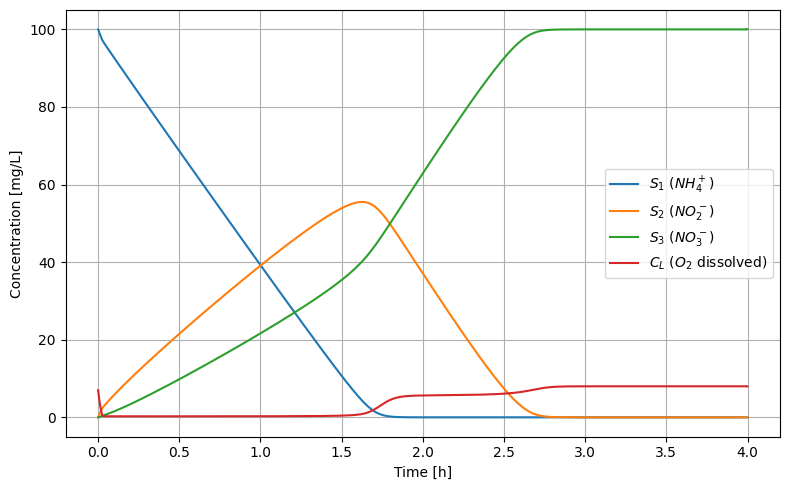

In [13]:
#Exercice 3.c)

#Value from b)
kLa = 30 #h^-1

# ODE system
def system(t, y):

    S1, S2, S3, CL = y

    S1 = max(S1, 0)
    S2 = max(S2, 0)
    CL = max(CL, 0)

    r1 = vm1 * S1/(K1 + S1) * CL/(KO1 + CL)
    r2 = vm2 * S2/(K2 + S2) * CL/(KO2 + CL)

    dS1dt = -r1
    dS2dt = r1 - r2
    dS3dt = r2

    dCLdt = (
        kLa * (CL_star - CL)
        - YO_S1 * r1
        - YO_S2 * r2
    )

    return [dS1dt, dS2dt, dS3dt, dCLdt]

# Solve ODE system
sol = solve_ivp(
    system,
    t_span=(0, 4),
    y0=y0,
    method='BDF',
    rtol=1e-8,
    atol=1e-10
)

# Extract solution
t = sol.t
S1 = sol.y[0]
S2 = sol.y[1]
S3 = sol.y[2]
CL = sol.y[3]

# Estimate depletion time for S1
threshold = 0.1  # mg/L

index = np.where(S1 <= threshold)[0][0]
t_depletion = t[index]

print(f"Approximate depletion time of S1 = {t_depletion:.2f} h")

# Plot species
plt.figure(figsize=(8,5))

plt.plot(t, S1, label=r"$S_1$ ($NH_4^+$)")
plt.plot(t, S2, label=r"$S_2$ ($NO_2^-$)")
plt.plot(t, S3, label=r"$S_3$ ($NO_3^-$)")
plt.plot(t, CL, label=r"$C_L$ ($O_2$ dissolved)")

plt.xlabel("Time [h]")
plt.ylabel("Concentration [mg/L]")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()